In [1]:
import os
from glob import glob
import nibabel as nib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from monai.transforms import (
    LoadImaged, EnsureChannelFirstd, Orientationd,
    ResizeWithPadOrCropd, Compose, NormalizeIntensityd
)
from monai.losses import DiceLoss
from monai.metrics import DiceMetric, HausdorffDistanceMetric
from monai.networks.nets import SwinUNETR
from monai.data import Dataset

import tensorflow as tf


In [2]:
### -------------------------------------------
print("TensorFlow GPU:", tf.config.list_physical_devices('GPU'))

###------------------------------------------
  # check if cpu version of python only
print(torch.version.cuda)        # should show e.g., 11.8
print(torch.cuda.is_available()) # should be True
print(torch.cuda.get_device_name(0)) # your GPU name

TensorFlow GPU: []
11.8
True
NVIDIA RTX A4000


In [3]:
# -----------------------------
# Paths (Windows)
# -----------------------------
data_dir = "E:/Dataset/ISLES-2022"
dwi_dir = os.path.join(data_dir, "DWI_NIFTI", "extracted_nii")
mask_dir = os.path.join(data_dir, "MASK_NIFTI", "extracted_nii")

print("DATA DIR:", data_dir)
print("DWI DIR:", dwi_dir)
print("MASK DIR:", mask_dir)

# List files
dwi_files = sorted(glob(os.path.join(dwi_dir, "*.nii")))
mask_files = sorted(glob(os.path.join(mask_dir, "*.nii")))

print(f"Found {len(dwi_files)} DWI images, {len(mask_files)} mask images.")

DATA DIR: E:/Dataset/ISLES-2022
DWI DIR: E:/Dataset/ISLES-2022\DWI_NIFTI\extracted_nii
MASK DIR: E:/Dataset/ISLES-2022\MASK_NIFTI\extracted_nii
Found 250 DWI images, 250 mask images.


In [4]:
# -----------------------------
# Preprocessing
# -----------------------------
target_shape = (96, 96, 96)

# Output folders for preprocessed images
output_dwi_dir = "E:/preprocessed_dwi"
output_mask_dir = "E:/preprocessed_mask"
os.makedirs(output_dwi_dir, exist_ok=True)
os.makedirs(output_mask_dir, exist_ok=True)

resize_transform = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    Orientationd(keys=["image"], axcodes="RAS"),
    ResizeWithPadOrCropd(keys=["image"], spatial_size=target_shape),
    NormalizeIntensityd(keys=["image"], nonzero=True)
])

mask_transform = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    Orientationd(keys=["image"], axcodes="RAS"),
    ResizeWithPadOrCropd(keys=["image"], spatial_size=target_shape)
])

for dwi_path, mask_path in tqdm(zip(dwi_files, mask_files), total=len(dwi_files), desc="Preprocessing"):
    # DWI
    dwi_data = {"image": dwi_path}
    dwi_out = resize_transform(dwi_data)
    dwi_img = dwi_out["image"]
    dwi_np = dwi_img[0].numpy()
    dwi_affine = nib.load(dwi_path).affine
    nib.save(nib.Nifti1Image(dwi_np, dwi_affine), os.path.join(output_dwi_dir, os.path.basename(dwi_path)))

    # Mask
    mask_data = {"image": mask_path}
    mask_out = mask_transform(mask_data)
    mask_img = mask_out["image"]
    mask_np = mask_img[0].numpy()
    mask_affine = nib.load(mask_path).affine
    nib.save(nib.Nifti1Image(mask_np, mask_affine), os.path.join(output_mask_dir, os.path.basename(mask_path)))

c:\Users\FAST\Desktop\swinUNet\venv\Lib\site-packages\monai\utils\deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)
Preprocessing: 100%|██████████| 250/250 [00:30<00:00,  8.29it/s]


In [5]:

# -----------------------------
# Train/Validation split
# -----------------------------
preprocessed_dwi_files = sorted(glob(os.path.join(output_dwi_dir, "*.nii")))
preprocessed_mask_files = sorted(glob(os.path.join(output_mask_dir, "*.nii")))

train_dwi, val_dwi, train_mask, val_mask = train_test_split(
    preprocessed_dwi_files, preprocessed_mask_files, test_size=0.2, random_state=42
)

train_files = [{"image": i, "mask": m} for i, m in zip(train_dwi, train_mask)]
val_files = [{"image": i, "mask": m} for i, m in zip(val_dwi, val_mask)]

train_transforms = Compose([LoadImaged(keys=["image","mask"]), EnsureChannelFirstd(keys=["image","mask"])])
val_transforms = Compose([LoadImaged(keys=["image","mask"]), EnsureChannelFirstd(keys=["image","mask"])])

train_ds = Dataset(data=train_files, transform=train_transforms)
val_ds = Dataset(data=val_files, transform=val_transforms)

train_loader = DataLoader(train_ds, batch_size=2, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=2, shuffle=False)


In [6]:

# -----------------------------
# Device
# -----------------------------
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda:0


In [7]:

# -----------------------------
# Model
# -----------------------------
model = SwinUNETR(
    in_channels=1,
    out_channels=1,
    feature_size=48,
    drop_rate=0.0,
    attn_drop_rate=0.0,
    dropout_path_rate=0.0,
    use_checkpoint=True
).to(device)


dice_loss = DiceLoss(sigmoid=True)
bce_loss = nn.BCEWithLogitsLoss()

def loss_function(y_pred, y_true):
    return 0.5 * dice_loss(y_pred, y_true) + 0.5 * bce_loss(y_pred, y_true)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
dice_metric = DiceMetric(include_background=False, reduction="mean")
hd_metric = HausdorffDistanceMetric(include_background=False, percentile=95, reduction="mean")

def iou_from_dice(dice):
    return dice / (2 - dice)


print(model)

SwinUNETR(
  (swinViT): SwinTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv3d(1, 48, kernel_size=(2, 2, 2), stride=(2, 2, 2))
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (layers1): ModuleList(
      (0): BasicLayer(
        (blocks): ModuleList(
          (0-1): 2 x SwinTransformerBlock(
            (norm1): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
            (attn): WindowAttention(
              (qkv): Linear(in_features=48, out_features=144, bias=True)
              (attn_drop): Dropout(p=0.0, inplace=False)
              (proj): Linear(in_features=48, out_features=48, bias=True)
              (proj_drop): Dropout(p=0.0, inplace=False)
              (softmax): Softmax(dim=-1)
            )
            (drop_path): Identity()
            (norm2): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
            (mlp): MLPBlock(
              (linear1): Linear(in_features=48, out_features=192, bias=True)
              (linear2): Linear(in_feature

In [8]:
# -----------------------------
# Checkpoints & TensorBoard logs
# -----------------------------
checkpoint_dir = "E:/SwinUNETR_SingleChannel_checkpoints"
log_dir = "E:/SwinUNETR_SingleChannel_logs"
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)
writer = SummaryWriter(log_dir=log_dir)

print(f"Checkpoints will be saved to: {checkpoint_dir}")
print(f"TensorBoard logs will be saved to: {log_dir}")

Checkpoints will be saved to: E:/SwinUNETR_SingleChannel_checkpoints
TensorBoard logs will be saved to: E:/SwinUNETR_SingleChannel_logs


In [9]:

# -----------------------------
# Training loop
# -----------------------------
best_dice = 0.0
history = {"train_loss": [], "val_loss":[], "val_dice": [], "val_iou": [], "val_hd95": []}
num_epochs = 50

for epoch in range(1, num_epochs+1):
    model.train()
    epoch_loss = 0
    for batch_idx, batch in enumerate(tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs}", leave=False)):
        images = batch["image"].to(device, dtype=torch.float32)
        masks = batch["mask"].to(device, dtype=torch.float32)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_function(outputs, masks)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        writer.add_scalar("train/loss_batch", loss.item(), epoch * len(train_loader) + batch_idx)

    avg_train_loss = epoch_loss / len(train_loader)
    history["train_loss"].append(avg_train_loss)
    writer.add_scalar("train/loss_epoch", avg_train_loss, epoch)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for val_batch in val_loader:
            val_images = val_batch["image"].to(device, dtype=torch.float32)
            val_masks = val_batch["mask"].to(device, dtype=torch.float32)

            val_outputs = model(val_images)
            loss_val = loss_function(val_outputs, val_masks)
            val_loss += loss_val.item()

            pred_binary = (torch.sigmoid(val_outputs) > 0.5).float()
            dice_metric(y_pred=pred_binary, y=val_masks)
            hd_metric(y_pred=pred_binary, y=val_masks)

    avg_val_loss = val_loss / len(val_loader)
    mean_dice = dice_metric.aggregate().item()
    mean_hd95 = hd_metric.aggregate().item()
    mean_iou = iou_from_dice(mean_dice)

    dice_metric.reset()
    hd_metric.reset()

    history["val_loss"].append(avg_val_loss)
    history["val_dice"].append(mean_dice)
    history["val_iou"].append(mean_iou)
    history["val_hd95"].append(mean_hd95)

    writer.add_scalar("val/loss_epoch", avg_val_loss, epoch)
    writer.add_scalar("val/dice", mean_dice, epoch)
    writer.add_scalar("val/iou", mean_iou, epoch)
    writer.add_scalar("val/hd95", mean_hd95, epoch)
    writer.flush()

    print(f"Epoch {epoch}: Train Loss={avg_train_loss:.4f} | Val Loss={avg_val_loss:.4f} | DSC={mean_dice:.4f} | IoU={mean_iou:.4f} | HD95={mean_hd95:.4f}")

    # Save best model
    if mean_dice > best_dice:
        best_dice = mean_dice
        best_model_path = os.path.join(checkpoint_dir, "best_model.pth")
        torch.save(model.state_dict(), best_model_path)
        print(f"Best model updated at epoch {epoch} with DSC={best_dice:.4f}")

writer.close()


c:\Users\FAST\Desktop\swinUNet\venv\Lib\site-packages\monai\utils\deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)


Epoch 1: Train Loss=0.6191 | Val Loss=0.5708 | DSC=0.2651 | IoU=0.1528 | HD95=36.2753
Best model updated at epoch 1 with DSC=0.2651


Epoch 2: Train Loss=0.5478 | Val Loss=0.5389 | DSC=0.2610 | IoU=0.1501 | HD95=34.3740


Epoch 3: Train Loss=0.5224 | Val Loss=0.5216 | DSC=0.2884 | IoU=0.1685 | HD95=34.2066
Best model updated at epoch 3 with DSC=0.2884


Epoch 4: Train Loss=0.5074 | Val Loss=0.5086 | DSC=0.3999 | IoU=0.2499 | HD95=29.2305
Best model updated at epoch 4 with DSC=0.3999


...

Epoch 46: Train Loss=0.0632 | Val Loss=0.1985 | DSC=0.6280 | IoU=0.4577 | HD95=14.3906


Epoch 47: Train Loss=0.0628 | Val Loss=0.2021 | DSC=0.6201 | IoU=0.4494 | HD95=16.4129


Epoch 48: Train Loss=0.0602 | Val Loss=0.1983 | DSC=0.6284 | IoU=0.4581 | HD95=14.5709


Epoch 49: Train Loss=0.0579 | Val Loss=0.1974 | DSC=0.6269 | IoU=0.4566 | HD95=13.8861


Epoch 50: Train Loss=0.0557 | Val Loss=0.1983 | DSC=0.6256 | IoU=0.4552 | HD95=14.6761


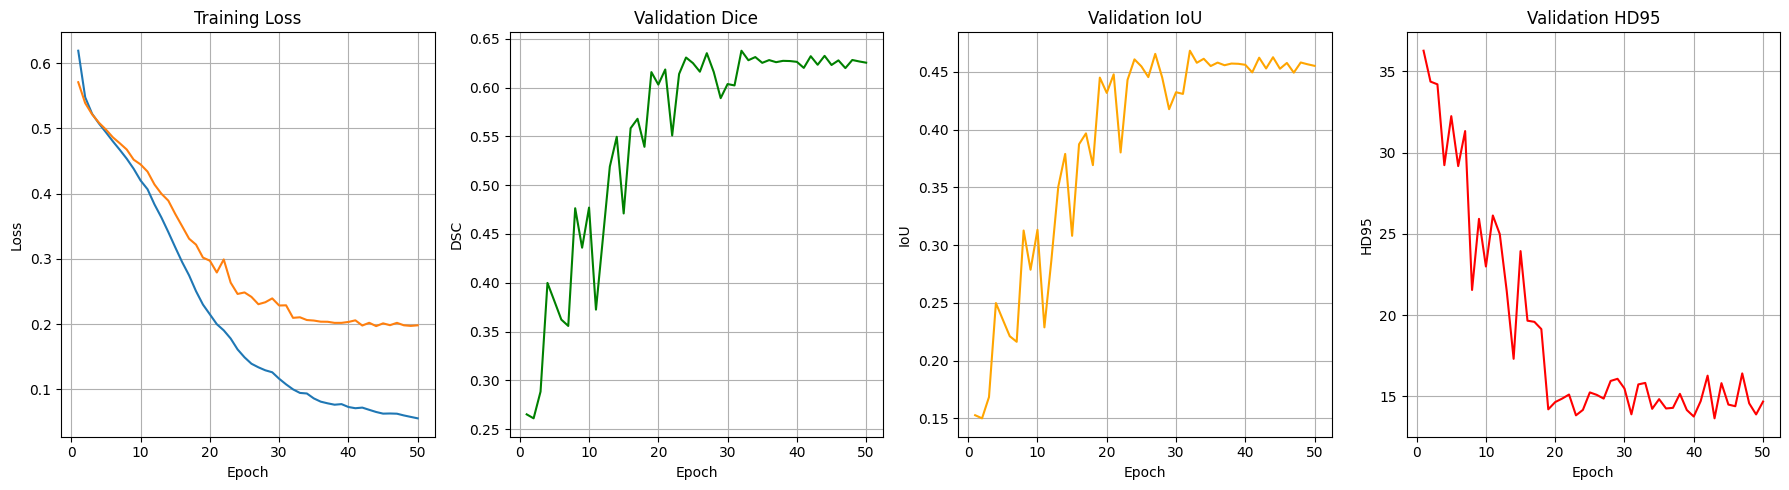

In [18]:
# ----------------------------
# Plot Training & Metrics
# ----------------------------
epochs = range(1, num_epochs+1)
plt.figure(figsize=(18,5))

# Training Loss
plt.subplot(1,4,1)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)

# Dice
plt.subplot(1,4,2)
plt.plot(epochs, history["val_dice"], label="Validation DSC", color="green")
plt.xlabel("Epoch")
plt.ylabel("DSC")
plt.title("Validation Dice")
plt.grid(True)

# IoU
plt.subplot(1,4,3)
plt.plot(epochs, history["val_iou"], label="Validation IoU", color="orange")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("Validation IoU")
plt.grid(True)

# HD95
plt.subplot(1,4,4)
plt.plot(epochs, history["val_hd95"], label="Validation HD95", color="red")
plt.xlabel("Epoch")
plt.ylabel("HD95")
plt.title("Validation HD95")
plt.grid(True)

plt.tight_layout()
plt.show()

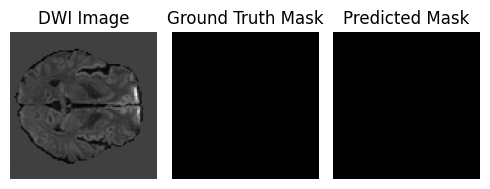

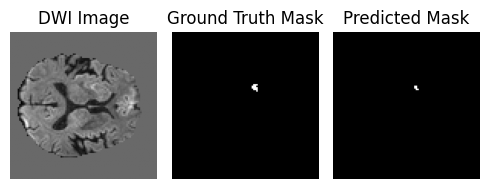

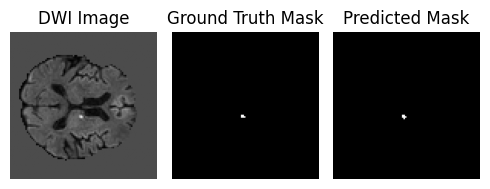

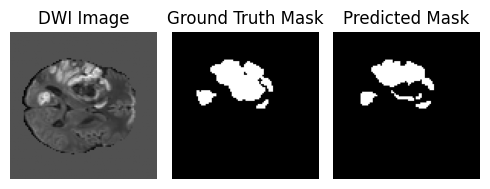

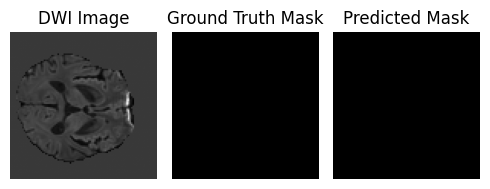

In [26]:
import random
def visualize_3d_predictions(model, dataset, device, num_samples=3):
    """
    Visualize num_samples random 3D volumes from the dataset.
    For each volume, show one slice: image, ground truth mask, predicted mask.
    """
    model.eval()
    indices = random.sample(range(len(dataset)), num_samples)
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            data = dataset[idx]
            img = data["image"].unsqueeze(0).to(device, dtype=torch.float32)  # [1, C, H, W, D]
            mask = data["mask"]  # tensor [C, H, W, D]

            # Model prediction
            pred = model(img)
            pred_sigmoid = torch.sigmoid(pred)[0,0].cpu()  # [H, W, D]

            # Pick middle slice along z-axis
            z = img.shape[-1] // 2
            img_slice = img[0,0,:,:,z].cpu().numpy()
            mask_slice = mask[0,:,:,z].numpy()
            pred_slice = (pred_sigmoid[:,:,z] > 0.5).numpy()  # binary mask

            # Plot
            plt.figure(figsize=(5,5))
            plt.subplot(1,3,1)
            plt.imshow(img_slice, cmap='gray')
            plt.title("DWI Image")
            plt.axis('off')

            plt.subplot(1,3,2)
            plt.imshow(mask_slice, cmap='gray')
            plt.title("Ground Truth Mask")
            plt.axis('off')

            plt.subplot(1,3,3)
            plt.imshow(pred_slice, cmap='gray')
            plt.title("Predicted Mask")
            plt.axis('off')

            plt.tight_layout()
            plt.show()
visualize_3d_predictions(model, val_ds, device, num_samples=5)

In [13]:
%load_ext tensorboard
%tensorboard --logdir E:/SwinUNETR_SingleChannel_logs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 16316), started 0:02:19 ago. (Use '!kill 16316' to kill it.)